In [58]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

In [59]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
meteo_doubs = pd.read_csv("../data/meteo/meteostat_doubs.csv")
doubs_voisins = pd.read_csv("../data/doubs_train_test/doubs_voisins.csv")

In [60]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [61]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [62]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [63]:
doubs_data.shape

(2679, 62)

In [64]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnies'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnies'].isna().sum()
print(f"Nombre de casernes sans id_compagnies : {none_count}")

print(caserne[['compagnie', 'id_compagnies']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnies : 0
         compagnie  id_compagnies
0         Besançon            1.0
1  Baume-les-Dames            2.0
2      Montbéliard            6.0
3       Pontarlier            4.0
4      Montbéliard            6.0


In [65]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnies'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnies'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnies'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnies']].head())

            hex_id id_compagnies
0  871f820aaffffff           4.0
1  871f82d61ffffff          12.0
2  871f82d61ffffff          12.0
3  871f82d4dffffff           1.0
4  871f82700ffffff           5.0


In [66]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_data['id_caserne'] = None
doubs_data['distance'] = None

for idx, hexagone in doubs_data.iterrows():
    casernes_same_company = caserne[caserne['id_compagnies'] == hexagone['id_compagnies']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_data.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_data.at[idx, 'distance'] = distances.min()

print(doubs_data[['hex_id', 'id_compagnies', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnies id_caserne  distance
0  871f820aaffffff           4.0     840709       0.0
1  871f82d61ffffff          12.0     840704  0.005327
2  871f82d61ffffff          12.0     840704  0.005327
3  871f82d4dffffff           1.0     840698  0.039716
4  871f82700ffffff           5.0     840701  0.010387


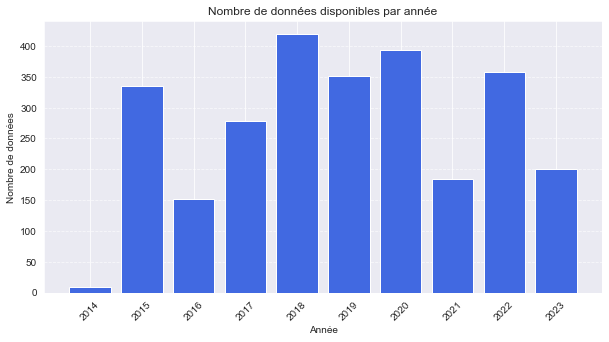

In [67]:
year_counts = doubs_data["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values, color="royalblue")
plt.xlabel("Année")
plt.ylabel("Nombre de données")
plt.title("Nombre de données disponibles par année")
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [68]:
print(year_counts)

2014.0      9
2015.0    335
2016.0    152
2017.0    278
2018.0    420
2019.0    351
2020.0    393
2021.0    184
2022.0    357
2023.0    200
Name: year, dtype: int64


In [69]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'id_compagnies', 'id_caserne',
       'distance'],
      dtype='object')

In [70]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'year', 'scale0', 'hour', 'month', 'weekday', 'distance'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

In [71]:
doubs_data.columns

Index(['hex_id', 'date', 'duree_minutes', 'geometry', 'centroid',
       'centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'id_compagnies'],
      dtype='object')

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -193.308183   365.771043  35.301036  49.568009  0.030354   
1   2.1  -207.285164   379.748023  37.570279  50.756412  0.041264   
2   2.2  -221.262145   393.725004  37.570279  50.756412  0.041264   
3   2.3  -235.239125   407.701985  37.456715  51.824335  0.063704   
4   2.4  -249.216106   421.678965  38.777120  55.530498  0.042433   
5   2.5  -263.193087   435.655946  37.191344  54.357449  0.082462   
6   2.6  -277.170067   449.632927  37.416691  53.991449 -0.016037   
7   2.7  -291.147048   463.609907  36.014943  52.960120  0.022409   
8   2.8  -305.124029   477.586888  36.578454  55.067346  0.026893   
9   2.9  -319.101009   491.563869  36.578454  55.067346  0.026893   
10  3.0  -333.077990   505.540849  37.234171  57.746589  0.023126   
11  3.1  -347.054971   519.517830  36.426815  56.146294  0.076518   
12  3.2  -361.031951   533.494811  37.683943  57.799374  0.021339   
13  3.3  -375.008932   547.471791 

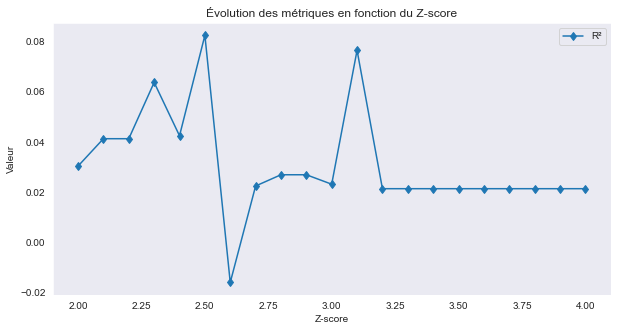

In [72]:
df = doubs_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

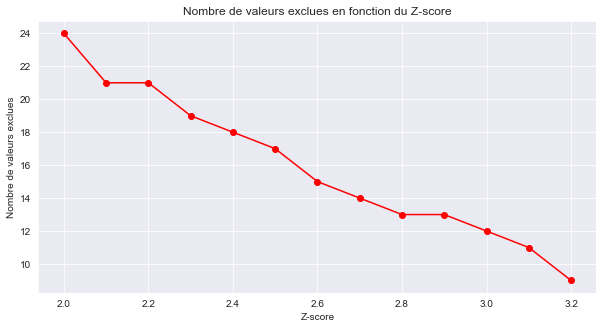

In [73]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

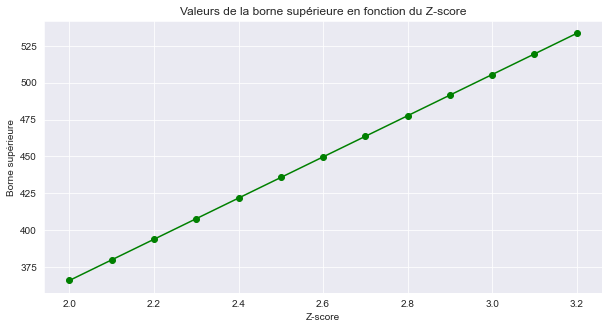

In [74]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [75]:
top_35_values = df['duree_minutes'].nlargest(35)

print(top_35_values)

1716    3885.850000
1199    3025.100000
1263    2753.933333
954     1725.383333
234     1667.683333
836     1629.883333
228     1625.983333
363     1500.500000
1112     920.333333
1341     531.866667
2583     530.733333
2590     510.183333
2853     504.333333
242      466.100000
2553     458.316667
160      443.816667
1931     437.516667
1173     435.516667
199      414.416667
2663     402.866667
505      398.400000
1804     373.866667
2419     371.916667
68       367.333333
1772     363.283333
260      359.183333
2778     358.000000
2767     357.716667
2816     355.216667
656      347.350000
0        345.533333
362      344.300000
937      342.533333
2297     331.250000
1009     326.916667
Name: duree_minutes, dtype: float64


In [76]:
doubs_data['z_score'] = np.abs(zscore(doubs_data['duree_minutes']))

doubs_data_filtered = doubs_data[doubs_data['z_score'] <= 2.9].drop(columns=['z_score'])

values_removed = len(doubs_data) - len(doubs_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(doubs_data) * 100:.2f}%")

Nombre de valeurs supprimées : 13
Pourcentage des données supprimées : 0.49%


In [77]:
doubs_data_filtered['date'] = pd.to_datetime(doubs_data_filtered['date'])
meteo_doubs['creneau'] = pd.to_datetime(meteo_doubs['creneau'])

meteo_doubs['geometry'] = [Point(xy) for xy in zip(meteo_doubs['longitude'], meteo_doubs['latitude'])]
meteo_gdf = gpd.GeoDataFrame(meteo_doubs, geometry='geometry', crs="EPSG:4326")

doubs_data_filtered = doubs_data_filtered.to_crs("EPSG:32631")
meteo_gdf = meteo_gdf.to_crs("EPSG:32631")

def trouver_meteo_proche(row, meteo_gdf):
    meteo_jour = meteo_gdf[meteo_gdf['creneau'] == row['date']]
    if meteo_jour.empty:
        return pd.Series([np.nan] * len(meteo_gdf.columns), index=meteo_gdf.columns)

    centroid = row.geometry.centroid
    centroid_x, centroid_y = centroid.x, centroid.y

    tree = cKDTree(np.array(list(zip(meteo_jour.geometry.x, meteo_jour.geometry.y))))
    dist, idx = tree.query([centroid_x, centroid_y], k=1)

    return meteo_jour.iloc[idx]

meteo_associee = doubs_data_filtered.apply(lambda row: trouver_meteo_proche(row, meteo_gdf), axis=1)

meteo_associee = meteo_associee.rename(columns={'geometry': 'geometry_meteo'})

doubs_data_filtered = pd.concat([doubs_data_filtered.reset_index(drop=True), meteo_associee.reset_index(drop=True)], axis=1)

doubs_data_filtered = doubs_data_filtered.loc[:, ~doubs_data_filtered.columns.duplicated()]

In [78]:
colonnes_a_supprimer = ['geometry_meteo', 'year', 'longitude', 'latitude', 'index', 'creneau']
doubs_data_filtered = doubs_data_filtered.drop(columns=colonnes_a_supprimer)

In [79]:
doubs_data_filtered = doubs_data_filtered.dropna()

In [80]:
test_size = 0.2
random_state = 42
hex_ids = doubs_data_filtered["hex_id"].unique()
splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(splitter.split(hex_ids, groups=hex_ids))
train_hex = hex_ids[train_idx]
test_hex = hex_ids[test_idx]
doubs_train = doubs_data_filtered[doubs_data_filtered["hex_id"].isin(train_hex)]
doubs_test = doubs_data_filtered[doubs_data_filtered["hex_id"].isin(test_hex)]
print(f"Taille du train : {doubs_train.shape[0]} lignes")
print(f"Taille du test : {doubs_test.shape[0]} lignes")

Taille du train : 1838 lignes
Taille du test : 487 lignes


In [81]:
common_hex = set(doubs_train["hex_id"]).intersection(set(doubs_test["hex_id"]))
if common_hex:
    print(f"Problème : {len(common_hex)} hex_id sont présents dans les deux datasets.")
else:
    print("Vérification réussie : Aucun hex_id en commun entre train et test.")

Vérification réussie : Aucun hex_id en commun entre train et test.


In [82]:
doubs_train = doubs_train.merge(doubs_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left')

doubs_test = doubs_test.merge(doubs_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left')

In [83]:
doubs_train['hex_voisins'] = doubs_train['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
doubs_test['hex_voisins'] = doubs_test['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(doubs_train['hex_voisins'].head())
print(doubs_test['hex_voisins'].head())

0    [871f82a2affffff, 871f82a05ffffff, 871f82a2bff...
1    [871f82040ffffff, 871f8204cffffff, 871f82044ff...
2    [871f80792ffffff, 871f82b6cffffff, 871f82b6dff...
3    [871f82c72ffffff, 871f82c55ffffff, 871f82c46ff...
4    [871f82b0dffffff, 871f82b2affffff, 871f82b01ff...
Name: hex_voisins, dtype: object
0    [871f82c0bffffff, 871f82c1dffffff, 871f82c72ff...
1    [871f82b68ffffff, 871f82b4cffffff, 871f82b6bff...
2    [871f82adeffffff, 871f82ad4ffffff, 871f82ac6ff...
3    [871f82885ffffff, 871f828a3ffffff, 871f828a8ff...
4    [871f82881ffffff, 871f828abffffff, 871f8288cff...
Name: hex_voisins, dtype: object


In [84]:
def get_statistics_for_neighbors(row, doubs_data):
    voisins_hex_ids = row['hex_voisins']

    filtered_df = doubs_data[doubs_data['hex_id'].isin(voisins_hex_ids)]

    statistics = {
        'voisins_moy': filtered_df['duree_minutes'].mean(),
        'voisins_medi': filtered_df['duree_minutes'].median(),
        'voisins_std': filtered_df['duree_minutes'].std(),
        'voisins_min': filtered_df['duree_minutes'].min(),
        'voisins_max': filtered_df['duree_minutes'].max(),
        'voisins_q1': filtered_df['duree_minutes'].quantile(0.25),
        'voisins_q3': filtered_df['duree_minutes'].quantile(0.75)
    }

    return statistics

for dataset in [doubs_train, doubs_test]:
    dataset[['voisins_moy', 'voisins_medi', 'voisins_std', 'voisins_min', 'voisins_max', 'voisins_q1', 'voisins_q3']] = dataset.apply(
        lambda row: pd.Series(get_statistics_for_neighbors(row, doubs_train)), axis=1)

print("Statistiques pour doubs_train :")
print(doubs_train[['voisins_moy', 'voisins_medi', 'voisins_std', 'voisins_min', 'voisins_max', 'voisins_q1', 'voisins_q3']].head())

print("\nStatistiques pour doubs_test :")
print(doubs_test[['voisins_moy', 'voisins_medi', 'voisins_std', 'voisins_min', 'voisins_max', 'voisins_q1', 'voisins_q3']].head())

Statistiques pour doubs_train :
   voisins_moy  voisins_medi  voisins_std  voisins_min  voisins_max  \
0   128.705952    105.916667    70.647288    49.166667   291.300000   
1    80.585714     67.666667    41.170063    47.383333   197.483333   
2    50.821348     42.775000    33.372092     1.416667   244.966667   
3    99.613636     87.175000    42.194429    45.450000   202.300000   
4    95.348990     69.166667    64.901583    37.016667   342.533333   

   voisins_q1  voisins_q3  
0   75.525000  158.320833  
1   56.525000   83.370833  
2   30.779167   60.587500  
3   71.104167  110.645833  
4   56.133333   99.783333  

Statistiques pour doubs_test :
   voisins_moy  voisins_medi  voisins_std  voisins_min  voisins_max  \
0   104.593939     81.016667    73.609635    45.450000   314.583333   
1    48.652412     40.525000    31.153352    11.583333   212.450000   
2    71.089583     69.000000    13.939347    53.816667   100.866667   
3    62.089057     50.966667    51.839588     1.266667   

In [85]:
doubs_train['nombre_voisins'] = doubs_train['hex_voisins'].apply(lambda x: len(x) if isinstance(x, list) else 0)

doubs_test['nombre_voisins'] = doubs_test['hex_voisins'].apply(lambda x: len(x) if isinstance(x, list) else 0)

voisins_train = doubs_train['nombre_voisins'].value_counts().sort_index()
voisins_test = doubs_test['nombre_voisins'].value_counts().sort_index()

print("Nombre de voisins dans doubs_train:")
print(voisins_train)

print("\nNombre de voisins dans doubs_test:")
print(voisins_test)

Nombre de voisins dans doubs_train:
0       6
1       3
2       8
3      19
4      50
5     109
6    1643
Name: nombre_voisins, dtype: int64

Nombre de voisins dans doubs_test:
2      4
3     13
4     21
5     12
6    437
Name: nombre_voisins, dtype: int64


In [86]:
doubs_train = doubs_train.fillna(0)
doubs_test = doubs_test.fillna(0)

In [87]:
doubs_train.isna().sum()

hex_id            0
date              0
duree_minutes     0
geometry          0
centroid          0
                 ..
voisins_min       0
voisins_max       0
voisins_q1        0
voisins_q3        0
nombre_voisins    0
Length: 106, dtype: int64

In [88]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

colonnes_a_exclure = ['duree_minutes', 'hex_id', 'nombre_voisins', 'hex_voisins', 'id_compagnies', 'centroid', 'date', 'geometry']
X_train = doubs_train.drop(columns=[col for col in colonnes_a_exclure if col in doubs_train.columns])
y_train = doubs_train['duree_minutes']

X_test = doubs_test.drop(columns=[col for col in colonnes_a_exclure if col in doubs_test.columns])
y_test = doubs_test['duree_minutes']

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = (mae, mse, rmse, r2)

print(f"{'Modèle':<20} {'MAE':<10} {'MSE':<15} {'RMSE':<10} {'R²':<10}")
print("="*60)
for name, (mae, mse, rmse, r2) in results.items():
    print(f"{name:<20} {mae:<10.4f} {mse:<15.4f} {rmse:<10.4f} {r2:<10.4f}")


Modèle               MAE        MSE             RMSE       R²        
Linear Regression    35.5141    3001.9077       54.7897    0.0817    
Random Forest        40.1220    3220.5099       56.7495    0.0148    
Gradient Boosting    37.8603    3112.3729       55.7886    0.0479    
XGBoost              43.8916    3819.9016       61.8054    -0.1685   
KNN                  41.7150    3730.4731       61.0776    -0.1412   
SVR                  35.5407    3362.5322       57.9873    -0.0286   


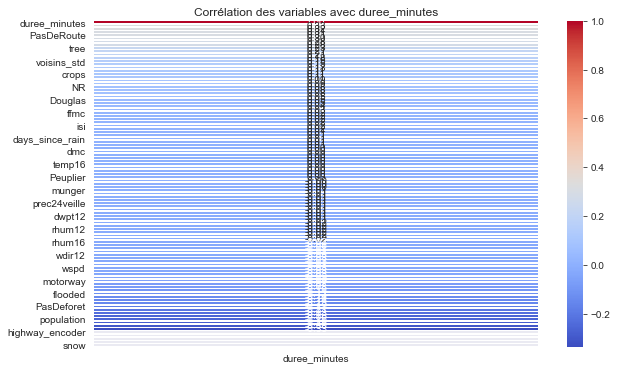

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = doubs_train.corr()

correlation_target = corr_matrix[['duree_minutes']].sort_values(by='duree_minutes', ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_target, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title("Corrélation des variables avec duree_minutes")
plt.show()

In [90]:
pd.set_option('display.max_rows', None)

correlation_values = doubs_train.corr()['duree_minutes'].sort_values(ascending=False)

print("Corrélation de chaque feature avec duree_minutes :\n")
print(correlation_values)

pd.reset_option('display.max_rows')

Corrélation de chaque feature avec duree_minutes :

duree_minutes               1.000000
voisins_q1                  0.329615
voisins_medi                0.323176
voisins_moy                 0.310344
PasDeRoute                  0.307441
voisins_min                 0.300271
voisins_q3                  0.283553
NDVI                        0.283180
tree                        0.232683
grass                       0.209776
NDMI                        0.206002
Mixte                       0.180608
voisins_std                 0.151345
elevation                   0.145254
id_compagnies               0.133714
shrub                       0.114384
crops                       0.109164
Mélèze                      0.108179
Sapin, épicéa               0.094685
foret_encoder               0.093032
NR                          0.082146
Pin sylvestre               0.082099
Feuillus                    0.079436
Chênes décidus              0.053356
Douglas                     0.048474
wspd16                 

In [91]:
cols_to_drop = correlation_values[correlation_values.isna()].index.tolist()

low_corr_cols = correlation_values[correlation_values.abs() < 0.05].index.tolist()

cols_to_remove = list(set(cols_to_drop + low_corr_cols))

X_train_clean = X_train.drop(columns=cols_to_remove)
X_test_clean = X_test.drop(columns=cols_to_remove)

print(f"Colonnes supprimées : {cols_to_remove}")

Colonnes supprimées : ['highway_encoder', 'temp', 'bui', 'snow', 'Conifères', 'prcp12', 'temp24max', 'snow24h', 'bare', 'temp12', 'prec24h12', 'munger', 'rhum12', 'Pin maritime', 'Pin autre', 'daily_severity_rating', 'Hêtre', 'nesterov', 'temp12h', 'prec24veille', 'sum_consecutive_rainfall', 'rhum', 'prec24h', 'sum_rain_last_7_days', 'sum_snow_last_7_days', 'angstroem', 'Douglas', 'Robinier', 'Peuplier', 'ffmc', 'days_since_rain', 'Pins mélangés', 'wspd16', 'dwpt12', 'dwpt16', 'prcp', 'temp15h', 'wdir', 'wspd12', 'pres', 'NC', 'kbdi', 'rhum12h', 'tertiary', 'dwpt', 'snow24h12', 'wdir12', 'snow24h16', 'rhum15h', 'wspd', 'fwi', 'Châtaignier', 'dc', 'prcp16', 'isi', 'prec24h16', 'temp16', 'dmc', 'Pin laricio, pin noir', 'rhum16']


In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import xgboost as xgb

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": xgb.XGBRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

results = {}

for name, model in models.items():
    model.fit(X_train_clean, y_train)
    y_pred = model.predict(X_test_clean)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}

print("Modèle               MAE        MSE             RMSE       R²")
print("============================================================")
for model_name, metrics in results.items():
    print(f"{model_name:<20} {metrics['MAE']:<10.4f} {metrics['MSE']:<10.4f} {metrics['RMSE']:<10.4f} {metrics['R²']:<10.4f}")

Modèle               MAE        MSE             RMSE       R²
Linear Regression    36.1484    2969.8826  54.4966    0.0915    
Random Forest        39.0954    3158.4748  56.2003    0.0338    
Gradient Boosting    40.5462    3435.0245  58.6091    -0.0508   
XGBoost              41.2985    3503.7585  59.1926    -0.0718   
KNN                  39.7342    3502.9744  59.1859    -0.0716   
SVR                  34.4546    3215.2236  56.7029    0.0164    


In [93]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
}

ridge = Ridge()

grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Meilleurs paramètres trouvés :", grid_search.best_params_)

best_ridge_model = grid_search.best_estimator_

y_pred_best_ridge = best_ridge_model.predict(X_test_scaled)

mae_best_ridge = mean_absolute_error(y_test, y_pred_best_ridge)
mse_best_ridge = mean_squared_error(y_test, y_pred_best_ridge)
rmse_best_ridge = np.sqrt(mse_best_ridge)
r2_best_ridge = r2_score(y_test, y_pred_best_ridge)

print(f"Best Ridge MAE: {mae_best_ridge:.4f}")
print(f"Best Ridge MSE: {mse_best_ridge:.4f}")
print(f"Best Ridge RMSE: {rmse_best_ridge:.4f}")
print(f"Best Ridge R²: {r2_best_ridge:.4f}")

Meilleurs paramètres trouvés : {'alpha': 100}
Best Ridge MAE: 35.0954
Best Ridge MSE: 2880.9989
Best Ridge RMSE: 53.6749
Best Ridge R²: 0.1187


In [95]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

param_grid_lgbm = {
    'num_leaves': [31, 50, 100],  # Nombre de feuilles
    'learning_rate': [0.05, 0.1, 0.2],  # Taux d'apprentissage
    'n_estimators': [100, 200, 500],  # Nombre d'arbres
    'max_depth': [5, 10, 15],  # Profondeur maximale des arbres
}

lgbm = lgb.LGBMRegressor()

grid_search_lgbm = GridSearchCV(lgbm, param_grid_lgbm, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search_lgbm.fit(X_train_scaled, y_train)

print("Meilleurs paramètres pour LightGBM :", grid_search_lgbm.best_params_)

best_lgbm_model = grid_search_lgbm.best_estimator_

y_pred_best_lgbm = best_lgbm_model.predict(X_test_scaled)

mae_best_lgbm = mean_absolute_error(y_test, y_pred_best_lgbm)
mse_best_lgbm = mean_squared_error(y_test, y_pred_best_lgbm)
rmse_best_lgbm = np.sqrt(mse_best_lgbm)
r2_best_lgbm = r2_score(y_test, y_pred_best_lgbm)

print(f"Best LightGBM MAE: {mae_best_lgbm:.4f}")
print(f"Best LightGBM MSE: {mse_best_lgbm:.4f}")
print(f"Best LightGBM RMSE: {rmse_best_lgbm:.4f}")
print(f"Best LightGBM R²: {r2_best_lgbm:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7254
[LightGBM] [Info] Number of data points in the train set: 1838, number of used features: 38
[LightGBM] [Info] Start training from score 78.251433
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

param_grid = {
    'n_estimators': [50, 100, 200],  # Nombre d'arbres dans la forêt
    'max_depth': [10, 20, 30, None],  # Profondeur maximale des arbres
    'min_samples_split': [2, 5, 10],  # Min échantillons requis pour un split
    'min_samples_leaf': [1, 2, 4],  # Min échantillons requis par feuille
    'max_features': ['auto', 'sqrt'],  # Nombre de features considérées pour un split
    'bootstrap': [True, False]  # Utilisation du bootstrap
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print("Meilleurs paramètres trouvés :", grid_search.best_params_)

best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test_scaled)

mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"Best RandomForest MAE: {mae_best_rf:.4f}")
print(f"Best RandomForest MSE: {mse_best_rf:.4f}")
print(f"Best RandomForest RMSE: {rmse_best_rf:.4f}")
print(f"Best RandomForest R²: {r2_best_rf:.4f}")

In [40]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

param_grid = {
    'C': [0.1, 1, 10, 100],  # Régularisation
    'epsilon': [0.01, 0.1, 0.5, 1],  # Largeur du tube d'insensibilité
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Type de noyau
    'gamma': ['scale', 'auto']  # Pour les noyaux poly, rbf, sigmoid
}

svr = SVR()

grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)

start_time = time.time()

grid_search.fit(X_train_scaled, y_train)

end_time = time.time()
elapsed_time = end_time - start_time

print("\n🚀 Meilleurs paramètres trouvés :", grid_search.best_params_)
print(f"⏳ Temps total d'exécution : {elapsed_time:.2f} secondes\n")

best_svr_model = grid_search.best_estimator_

y_pred_best_svr = best_svr_model.predict(X_test_scaled)

mae_best_svr = mean_absolute_error(y_test, y_pred_best_svr)
mse_best_svr = mean_squared_error(y_test, y_pred_best_svr)
rmse_best_svr = np.sqrt(mse_best_svr)
r2_best_svr = r2_score(y_test, y_pred_best_svr)

print(f"Best SVR MAE: {mae_best_svr:.4f}")
print(f"Best SVR MSE: {mse_best_svr:.4f}")
print(f"Best SVR RMSE: {rmse_best_svr:.4f}")
print(f"Best SVR R²: {r2_best_svr:.4f}")

Fitting 5 folds for each of 128 candidates, totalling 640 fits

🚀 Meilleurs paramètres trouvés : {'C': 10, 'epsilon': 1, 'gamma': 'auto', 'kernel': 'rbf'}
⏳ Temps total d'exécution : 121.11 secondes

Best SVR MAE: 32.4711
Best SVR MSE: 2932.3402
Best SVR RMSE: 54.1511
Best SVR R²: 0.1030


In [41]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

param_grid = {
    'C': [0.1, 1, 10, 100],          # Pénalisation
    'epsilon': [0.01, 0.1, 0.5, 1],  # Largeur du tube d'insensibilité
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Noyaux à tester
    'gamma': ['scale', 'auto']        # Paramètre gamma pour certains noyaux
}

svr = SVR()

grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)

start_time = time.time()

grid_search.fit(X_train_scaled, y_train)

end_time = time.time()
elapsed_time = end_time - start_time

print("\nMeilleurs paramètres trouvés :", grid_search.best_params_)
print(f"Temps total d'exécution : {elapsed_time:.2f} secondes\n")

best_svr_model = grid_search.best_estimator_

y_pred_best_svr = best_svr_model.predict(X_test_scaled)

mae_best_svr = mean_absolute_error(y_test, y_pred_best_svr)
mse_best_svr = mean_squared_error(y_test, y_pred_best_svr)
rmse_best_svr = np.sqrt(mse_best_svr)
r2_best_svr = r2_score(y_test, y_pred_best_svr)

print(f"Best SVM MAE: {mae_best_svr:.4f}")
print(f"Best SVM MSE: {mse_best_svr:.4f}")
print(f"Best SVM RMSE: {rmse_best_svr:.4f}")
print(f"Best SVM R²: {r2_best_svr:.4f}")

Fitting 5 folds for each of 128 candidates, totalling 640 fits

Meilleurs paramètres trouvés : {'C': 10, 'epsilon': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Temps total d'exécution : 115.37 secondes

Best SVM MAE: 32.4711
Best SVM MSE: 2932.3402
Best SVM RMSE: 54.1511
Best SVM R²: 0.1030


In [47]:
import numpy as np
import time
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Définition des hyperparamètres pour chaque modèle
param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}
param_grid_svr = {'C': [0.1, 1, 10], 'epsilon': [0.01, 0.1], 'kernel': ['rbf']}
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}

# Stocker les meilleurs paramètres
best_params = {}

# Fonction pour afficher le temps restant
def display_progress(start_time, current_iter, total_iter):
    elapsed_time = time.time() - start_time
    avg_time_per_iter = elapsed_time / (current_iter + 1)
    remaining_time = avg_time_per_iter * (total_iter - current_iter - 1)
    print(f"⏳ Progression : {current_iter + 1}/{total_iter} - Temps restant estimé : {remaining_time:.2f} sec")

# Optimisation des hyperparamètres
start_time = time.time()

grids = {
    "Ridge": (Ridge(), param_grid_ridge),
    "SVR": (SVR(), param_grid_svr),
    "RandomForest": (RandomForestRegressor(random_state=42), param_grid_rf),
}

for i, (name, (model, param_grid)) in enumerate(grids.items()):
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    best_params[name] = grid_search.best_params_
    display_progress(start_time, i, len(grids))
    print(f"✅ {name} - Meilleurs paramètres : {best_params[name]}")

# Création des modèles avec les meilleurs paramètres
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=best_params["Ridge"]['alpha']),
    "SVR": SVR(**best_params["SVR"]),
    "RandomForest": RandomForestRegressor(**best_params["RandomForest"], random_state=42, n_jobs=-1)
}

# Évaluation des modèles avec Cross-Validation
print("\n📊 Évaluation des modèles avec Cross-Validation (5-Fold) :")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name}: R² moyen = {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Entraînement et test des modèles optimisés
print("\n🚀 Entraînement et test des modèles optimisés :")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n📌 {name}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

⏳ Progression : 1/3 - Temps restant estimé : 0.78 sec
✅ Ridge - Meilleurs paramètres : {'alpha': 100}
⏳ Progression : 2/3 - Temps restant estimé : 7.09 sec
✅ SVR - Meilleurs paramètres : {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
⏳ Progression : 3/3 - Temps restant estimé : 0.00 sec
✅ RandomForest - Meilleurs paramètres : {'max_depth': 10, 'n_estimators': 200}

📊 Évaluation des modèles avec Cross-Validation (5-Fold) :
LinearRegression: R² moyen = 0.1284 ± 0.0523
Ridge: R² moyen = 0.1435 ± 0.0458
SVR: R² moyen = 0.0898 ± 0.0336
RandomForest: R² moyen = 0.0773 ± 0.0684

🚀 Entraînement et test des modèles optimisés :

📌 LinearRegression
MAE: 36.0747
MSE: 2971.5072
RMSE: 54.5115
R²: 0.0910

📌 Ridge
MAE: 35.1107
MSE: 2884.0293
RMSE: 53.7032
R²: 0.1177

📌 SVR
MAE: 32.3724
MSE: 2926.1145
RMSE: 54.0936
R²: 0.1049

📌 RandomForest
MAE: 38.7162
MSE: 3113.7381
RMSE: 55.8009
R²: 0.0475


In [50]:
import numpy as np
import time
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Suppression des colonnes non utilisées
X_train = doubs_train.drop(columns=['duree_minutes', 'hex_id', 'nombre_voisins', 'hex_voisins', 'id_compagnies', 'centroid', 'date', 'geometry'])
y_train = doubs_train['duree_minutes']
X_test = doubs_test.drop(columns=['duree_minutes', 'hex_id', 'nombre_voisins', 'hex_voisins', 'id_compagnies', 'centroid', 'date', 'geometry'])
y_test = doubs_test['duree_minutes']

# Nettoyer les noms de colonnes pour éviter les erreurs avec LightGBM
X_train.columns = X_train.columns.str.replace(r'[^\w]', '_', regex=True)
X_test.columns = X_test.columns.str.replace(r'[^\w]', '_', regex=True)

# Modèles et hyperparamètres
models_params = {
    "XGBoost": {
        "model": XGBRegressor(objective="reg:squarederror", random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 6, 9],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    },
    "LightGBM": {
        "model": LGBMRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "num_leaves": [31, 50],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    },
    "CatBoost": {
        "model": CatBoostRegressor(verbose=0, random_state=42),
        "params": {
            "iterations": [100, 200],
            "depth": [6, 8, 10],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    }
}

best_models = {}
progress = 1
total = len(models_params)

print("\n🔍 Optimisation des modèles...\n")

# Optimisation des modèles
for name, config in models_params.items():
    print(f"⏳ Progression : {progress}/{total} - Optimisation de {name}...")
    start_time = time.time()

    grid_search = GridSearchCV(config["model"], config["params"], cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    elapsed_time = time.time() - start_time

    print(f"✅ {name} - Meilleurs paramètres : {grid_search.best_params_} ({elapsed_time:.2f} sec)")
    progress += 1

print("\n📊 Évaluation des modèles avec Cross-Validation (5-Fold) :")
for name, model in best_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    print(f"{name}: R² moyen = {scores.mean():.4f} ± {scores.std():.4f}")

# Entraînement des meilleurs modèles et test sur doubs_test
print("\n🚀 Entraînement et test des modèles optimisés :\n")
for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"📌 {name}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}\n")



🔍 Optimisation des modèles...

⏳ Progression : 1/3 - Optimisation de XGBoost...
✅ XGBoost - Meilleurs paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200} (120.86 sec)
⏳ Progression : 2/3 - Optimisation de LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14235
[LightGBM] [Info] Number of data points in the train set: 1838, number of used features: 91
[LightGBM] [Info] Start training from score 78.251433
✅ LightGBM - Meilleurs paramètres : {'learning_rate': 0.01, 'n_estimators': 200, 'num_leaves': 31} (80.76 sec)
⏳ Progression : 3/3 - Optimisation de CatBoost...
✅ CatBoost - Meilleurs paramètres : {'depth': 6, 'iterations': 100, 'learning_rate': 0.1} (490.63 sec)

📊 Évaluation des modèles avec Cross-Validation (5-Fold) :
XGBoost: R² moyen = 0.1433 ± 0.0425
[LightGBM] [Info] Auto-choosing col-wise multi-threading, 

In [51]:
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Définition des modèles et des grilles d'hyperparamètres
models = {
    "GradientBoosting": {
        "model": GradientBoostingRegressor(),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.1],
            "max_depth": [3, 5]
        }
    },
    "ExtraTrees": {
        "model": ExtraTreesRegressor(),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20]
        }
    },
    "MLPRegressor": {
        "model": MLPRegressor(max_iter=500),
        "params": {
            "hidden_layer_sizes": [(50,), (100,), (50, 50)],
            "alpha": [0.0001, 0.001],
            "learning_rate_init": [0.001, 0.01]
        }
    }
}

# Entraînement et évaluation des modèles
best_models = {}
for name, config in models.items():
    print(f"⏳ Optimisation de {name}...")

    grid_search = GridSearchCV(config["model"], config["params"], cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_
    print(f"✅ {name} - Meilleurs paramètres : {grid_search.best_params_}")

    # Évaluation sur le jeu de test
    y_pred = best_models[name].predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"📌 {name} - Performance sur le test:")
    print(f"MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}\n")

⏳ Optimisation de GradientBoosting...
✅ GradientBoosting - Meilleurs paramètres : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
📌 GradientBoosting - Performance sur le test:
MAE: 37.3194 | MSE: 2995.5930 | RMSE: 54.7320 | R²: 0.0836

⏳ Optimisation de ExtraTrees...
✅ ExtraTrees - Meilleurs paramètres : {'max_depth': 10, 'n_estimators': 200}
📌 ExtraTrees - Performance sur le test:
MAE: 38.0736 | MSE: 2980.8938 | RMSE: 54.5976 | R²: 0.0881

⏳ Optimisation de MLPRegressor...
✅ MLPRegressor - Meilleurs paramètres : {'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001}
📌 MLPRegressor - Performance sur le test:
MAE: 39.1059 | MSE: 3187.1904 | RMSE: 56.4552 | R²: 0.0250



In [52]:
import optuna
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

# Définir les objectifs de l'optimisation pour chaque modèle
def optimize_xgboost(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0)
    }

    model = XGBRegressor(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return r2

def optimize_lightgbm(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }

    model = LGBMRegressor(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return r2

def optimize_catboost(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 128)
    }

    model = CatBoostRegressor(**param, silent=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return r2

def optimize_randomforest(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['auto', 'sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }

    model = RandomForestRegressor(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    return r2

# Définir l'étude d'optimisation pour chaque modèle
def optimize_model(model_name):
    if model_name == 'XGBoost':
        study = optuna.create_study(direction='maximize')
        study.optimize(optimize_xgboost, n_trials=50)
    elif model_name == 'LightGBM':
        study = optuna.create_study(direction='maximize')
        study.optimize(optimize_lightgbm, n_trials=50)
    elif model_name == 'CatBoost':
        study = optuna.create_study(direction='maximize')
        study.optimize(optimize_catboost, n_trials=50)
    elif model_name == 'RandomForest':
        study = optuna.create_study(direction='maximize')
        study.optimize(optimize_randomforest, n_trials=50)
    else:
        raise ValueError("Model not supported!")

    return study.best_params, study.best_value

# Exécution des optimisations pour chaque modèle
xgboost_best_params, xgboost_best_r2 = optimize_model('XGBoost')
lightgbm_best_params, lightgbm_best_r2 = optimize_model('LightGBM')
catboost_best_params, catboost_best_r2 = optimize_model('CatBoost')
randomforest_best_params, randomforest_best_r2 = optimize_model('RandomForest')

# Affichage des meilleurs résultats
print(f"XGBoost - Meilleurs paramètres : {xgboost_best_params} | R² : {xgboost_best_r2}")
print(f"LightGBM - Meilleurs paramètres : {lightgbm_best_params} | R² : {lightgbm_best_r2}")
print(f"CatBoost - Meilleurs paramètres : {catboost_best_params} | R² : {catboost_best_r2}")
print(f"RandomForest - Meilleurs paramètres : {randomforest_best_params} | R² : {randomforest_best_r2}")

[I 2025-03-10 11:16:33,395] A new study created in memory with name: no-name-c685f455-7291-44d6-b292-e28725c1eb67
[I 2025-03-10 11:16:43,346] Trial 0 finished with value: -0.04565576339734512 and parameters: {'n_estimators': 241, 'learning_rate': 0.07095622681986537, 'max_depth': 4, 'subsample': 0.934798087432113, 'colsample_bytree': 0.772913817174171, 'gamma': 0.28729045566334865, 'reg_alpha': 0.6569246620093735, 'reg_lambda': 0.25915013658909836}. Best is trial 0 with value: -0.04565576339734512.
[I 2025-03-10 11:16:46,889] Trial 1 finished with value: -0.05104052457578767 and parameters: {'n_estimators': 285, 'learning_rate': 0.09694007003753127, 'max_depth': 3, 'subsample': 0.8151267644508398, 'colsample_bytree': 0.9627972796946487, 'gamma': 0.5032663446453634, 'reg_alpha': 0.524680603164546, 'reg_lambda': 0.3255247695304616}. Best is trial 0 with value: -0.04565576339734512.
[I 2025-03-10 11:16:59,510] Trial 2 finished with value: -0.032630445181085266 and parameters: {'n_estimato

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004500 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14235
[LightGBM] [Info] Number of data points in the train set: 1838, number of used features: 91
[LightGBM] [Info] Start training from score 78.251433
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2025-03-10 11:19:21,017] Trial 0 finished with value: 0.0016356018171275188 and parameters: {'n_estimators': 134, 'learning_rate': 0.0622637267711786, 'max_depth': 9, 'num_leaves': 60, 'subsample': 0.675936999844308, 'colsample_bytree': 0.9712502265633394}. Best is trial 0 with value: 0.0016356018171275188.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-03-10 11:19:21,706] Trial 1 finished with value: -0.004378904133871542 and parameters: {'n_estimators': 370, 'learning_rate': 0.07030350171320503, 'max_depth': 4, 'num_leaves': 87, 'subsample': 0.8455963214073129, 'colsample_bytree': 0.668799338899728}. Best is trial 0 with value: 0.0016356018171275188.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-03-10 11:19:55,402] Trial 49 finished with value: 0.08018795694452652 and parameters: {'n_estimators': 215, 'learning_rate': 0.02382110152845339, 'max_depth': 3, 'num_leaves': 50, 'subsample': 0.922008605518657, 'colsample_bytree': 0.6159362296768535}. Best is trial 30 with value: 0.103395436408106.
[I 2025-03-10 11:19:55,405] A new study created in memory with name: no-name-28fdb427-c78e-4360-ae33-7c4c2321bb25


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-03-10 11:19:58,228] Trial 0 finished with value: 0.04234826716996509 and parameters: {'iterations': 357, 'learning_rate': 0.08660425384610455, 'depth': 6, 'l2_leaf_reg': 1.5700084852214047, 'subsample': 0.8605379937835339, 'border_count': 80}. Best is trial 0 with value: 0.04234826716996509.
[I 2025-03-10 11:20:01,390] Trial 1 finished with value: 0.07086448872097661 and parameters: {'iterations': 498, 'learning_rate': 0.07220152396283588, 'depth': 6, 'l2_leaf_reg': 8.721067784975089, 'subsample': 0.6007283714902133, 'border_count': 57}. Best is trial 1 with value: 0.07086448872097661.
[I 2025-03-10 11:20:02,123] Trial 2 finished with value: 0.09711091131149385 and parameters: {'iterations': 290, 'learning_rate': 0.0390140573790163, 'depth': 3, 'l2_leaf_reg': 5.131598656126215, 'subsample': 0.9865090044188937, 'border_count': 38}. Best is trial 2 with value: 0.09711091131149385.
[I 2025-03-10 11:20:02,872] Trial 3 finished with value: 0.11591321787162467 and parameters: {'itera

XGBoost - Meilleurs paramètres : {'n_estimators': 146, 'learning_rate': 0.019103465221744064, 'max_depth': 3, 'subsample': 0.9171115130460828, 'colsample_bytree': 0.6036486448006166, 'gamma': 0.992264707460246, 'reg_alpha': 0.40828645707113964, 'reg_lambda': 0.2314483022799515} | R² : 0.09406226210836255
LightGBM - Meilleurs paramètres : {'n_estimators': 140, 'learning_rate': 0.047247243979946535, 'max_depth': 4, 'num_leaves': 39, 'subsample': 0.9739306305132134, 'colsample_bytree': 0.631853531937441} | R² : 0.103395436408106
CatBoost - Meilleurs paramètres : {'iterations': 170, 'learning_rate': 0.03217716500548145, 'depth': 4, 'l2_leaf_reg': 3.0520102003617335, 'subsample': 0.6641325469560695, 'border_count': 32} | R² : 0.12295417246405671
RandomForest - Meilleurs paramètres : {'n_estimators': 444, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True} | R² : 0.11487953496630987


In [53]:
# Importation des bibliothèques nécessaires
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Entraînement des modèles avec les meilleurs paramètres trouvés

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=146,
    learning_rate=0.0191,
    max_depth=3,
    subsample=0.917,
    colsample_bytree=0.604,
    gamma=0.992,
    reg_alpha=0.408,
    reg_lambda=0.231
)
xgb_model.fit(X_train, y_train)

# LightGBM
lgb_model = LGBMRegressor(
    n_estimators=140,
    learning_rate=0.0472,
    max_depth=4,
    num_leaves=39,
    subsample=0.974,
    colsample_bytree=0.632
)
lgb_model.fit(X_train, y_train)

# CatBoost
catboost_model = CatBoostRegressor(
    iterations=170,
    learning_rate=0.0322,
    depth=4,
    l2_leaf_reg=3.052,
    subsample=0.664,
    border_count=32,
    verbose=0
)
catboost_model.fit(X_train, y_train)

# RandomForest
rf_model = RandomForestRegressor(
    n_estimators=444,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=7,
    max_features='sqrt',
    bootstrap=True
)
rf_model.fit(X_train, y_train)

# Prédictions des modèles
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)
catboost_pred = catboost_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Calcul des métriques de performance
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# Évaluation des modèles
xgb_metrics = evaluate_model(y_test, xgb_pred)
lgb_metrics = evaluate_model(y_test, lgb_pred)
catboost_metrics = evaluate_model(y_test, catboost_pred)
rf_metrics = evaluate_model(y_test, rf_pred)

# Affichage des résultats
models = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']
metrics = [xgb_metrics, lgb_metrics, catboost_metrics, rf_metrics]
for model, metric in zip(models, metrics):
    print(f"{model}: MAE={metric[0]:.4f}, MSE={metric[1]:.4f}, RMSE={metric[2]:.4f}, R²={metric[3]:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14235
[LightGBM] [Info] Number of data points in the train set: 1838, number of used features: 91
[LightGBM] [Info] Start training from score 78.251433
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [54]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

# Définition de la fonction d'optimisation
def objective(trial):
    # Définition des hyperparamètres à tester
    params = {
        'iterations': 100,
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 1e-1),
        'depth': trial.suggest_int('depth', 3, 7),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-5, 10),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'verbose': 0
    }

    # Entraînement du modèle
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train)

    # Prédictions et évaluation sur les données de test
    y_pred = model.predict(X_test)
    return mean_squared_error(y_test, y_pred)

# Optimisation avec Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Affichage des meilleurs hyperparamètres
print("Best hyperparameters:", study.best_params)

# Entraînement final avec les meilleurs hyperparamètres
best_params = study.best_params
final_model = CatBoostRegressor(**best_params)
final_model.fit(X_train, y_train)

# Prédictions et métriques sur le test
y_pred = final_model.predict(X_test)
mae, mse, rmse, r2 = evaluate_model(y_test, y_pred)

print(f"Optimized CatBoost - MAE={mae:.4f}, MSE={mse:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")


[I 2025-03-10 11:51:21,472] A new study created in memory with name: no-name-898861d3-25d4-4262-8bb3-3a30a04046f0
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
[I 2025-03-10 11:51:24,352] Trial 0 finished with value: 3268.3627524503117 and parameters: {'learning_rate': 1.0398291523526406e-05, 'depth': 7, 'l2_leaf_reg': 5.261213586578387e-05, 'subsample': 0.680194367363617, 'border_count': 230}. Best is trial 0 with value: 3268.3627524503117.
suggest_loguniform has been deprecated in v3.0.0

Best hyperparameters: {'learning_rate': 0.05688890441317734, 'depth': 6, 'l2_leaf_reg': 0.12034627874601576, 'subsample': 0.9426525104793289, 'border_count': 138}
0:	learn: 53.6804283	total: 7.32ms	remaining: 7.32s
1:	learn: 53.2192132	total: 14.4ms	remaining: 7.2s
2:	learn: 52.7651396	total: 21.2ms	remaining: 7.05s
3:	learn: 52.2776027	total: 28.8ms	remaining: 7.18s
4:	learn: 51.8920915	total: 38ms	remaining: 7.56s
5:	learn: 51.4712357	total: 50.6ms	remaining: 8.38s
6:	learn: 51.1632884	total: 58.4ms	remaining: 8.28s
7:	learn: 50.8176683	total: 66.9ms	remaining: 8.3s
8:	learn: 50.4787784	total: 77.9ms	remaining: 8.58s
9:	learn: 50.1194896	total: 87ms	remaining: 8.61s
10:	learn: 49.8568221	total: 97.1ms	remaining: 8.73s
11:	learn: 49.5829838	total: 105ms	remaining: 8.67s
12:	learn: 49.2266621	total: 113ms	remaining: 8.56s
13:	learn: 48.9644545	total: 121ms	remaining: 8.54s
14:	learn: 48.8328305	total: 130ms	remaining: 8.57s
15:	learn: 48.5636003	total: 141ms	remaining: 8.66s
16:	learn:

In [56]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

# Initialisation des modèles de base
catboost_model = CatBoostRegressor(iterations=170, learning_rate=0.032, depth=4, l2_leaf_reg=3.05)
xgb_model = xgb.XGBRegressor(n_estimators=146, learning_rate=0.0191, max_depth=3)
rf_model = RandomForestRegressor(n_estimators=444, max_depth=7, min_samples_split=2, min_samples_leaf=7)

# Modèle métamodèle (par exemple, régression linéaire)
meta_model = LinearRegression()

# Stack des modèles
stacking_model = StackingRegressor(
    estimators=[('catboost', catboost_model), ('xgb', xgb_model), ('rf', rf_model)],
    final_estimator=meta_model
)

# Entraînement du modèle
stacking_model.fit(X_train, y_train)

# Prédiction et évaluation
y_pred = stacking_model.predict(X_test)

# Calcul des métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Stacking - MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R²: {r2}")

0:	learn: 53.9402341	total: 11.5ms	remaining: 1.94s
1:	learn: 53.7130099	total: 16.3ms	remaining: 1.37s
2:	learn: 53.5006812	total: 26.4ms	remaining: 1.47s
3:	learn: 53.2922691	total: 32.8ms	remaining: 1.36s
4:	learn: 53.1243565	total: 46.7ms	remaining: 1.54s
5:	learn: 52.9505245	total: 54.7ms	remaining: 1.5s
6:	learn: 52.7637212	total: 60.4ms	remaining: 1.41s
7:	learn: 52.6251844	total: 66.4ms	remaining: 1.34s
8:	learn: 52.4332072	total: 72.1ms	remaining: 1.29s
9:	learn: 52.2985959	total: 79.5ms	remaining: 1.27s
10:	learn: 52.1104241	total: 86.1ms	remaining: 1.25s
11:	learn: 51.9827656	total: 91.9ms	remaining: 1.21s
12:	learn: 51.8401460	total: 96.9ms	remaining: 1.17s
13:	learn: 51.7037460	total: 103ms	remaining: 1.15s
14:	learn: 51.5916800	total: 108ms	remaining: 1.12s
15:	learn: 51.4496799	total: 116ms	remaining: 1.11s
16:	learn: 51.3234553	total: 121ms	remaining: 1.08s
17:	learn: 51.2136989	total: 126ms	remaining: 1.06s
18:	learn: 51.0927736	total: 134ms	remaining: 1.07s
19:	learn: